# POLISCI 3

## Week 9, Notebook Lecture 1: Discontinuity Designs



In the Week 9 in-class lecture before spring break, we learned about "discontinuity designs."

We talked first about perhaps the most classic example (the first application of this kind of research design): Thistlewaite and Campbell's study of the impact of recognition of academic achievement on interest in a scholarly career.

In that design, we compared students who had just scored above a threshold score for recognition (the threshold was normalized to a score of 11 in our example) to those who had scored just below the threshold.

In general, comparing high scorers on exams to low scorers could lead to confounding: e.g., there might be other background factors (omitted variables) that make high scorers more interested in scholarly careers.  For example, they might come from families that value academic achievement and scholarly careers.  Those confounding factors, in general, make it difficult to distinguish the influence of the confounders from any effect of recognition of academic achievement.

But the key idea in a regression-discontinuity design is that while the treatment (here, recognition) changes sharply at the threshold (here, the cutoff score of 11), the confounding factors do not.  People who score 11.5 should have similar backgrounds, abilities, etc. as students who score 10.5.  It is as if there is an element of "chance" in whether a student happens to score 11.5 or 10.5 on this particular exam.  It is almost as if there is a local experiment, where students are (as-if) random assigned to the treatment group or the control group near the cutoff.

So, we make comparisons narrowly around the threshold score of 11, to try to get rid of confounding and estimate the effect of recognition.

In the in-class lecture, we discussed three other examples of discontinuity designs in political science: Hidalgo's study of the impact of electronic voting in Brazil; Lee's study of party incumbency advantage using a close-election design; and Carter's geographic discontinuity design that studies the impact of forced labor coercion on mobilization by indigenous communities in Peru.

In this Notebook Lecture, we'll look more into Hidalgo's study of electronic voting.  We'll use some R skills we already have and learn a some new ones as well.


In [1]:
# Load the libraries we'll need

library(estimatr)
library(rdrobust)

# Load Hidalgo's data set on electronic voting in Brazil

brazil.data <- read.csv("hidalgo_brazil_PS3.csv")
head(brazil.data)

,ibge.municode,uf,muni,electorate.96,comp.voting.98,depfedbranconulo98.pct,blank.inv.96,poverty_high_1991,frac_25_illit_1991,gini_1991,pt_pres_1994,latitude,longitude
,<int>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1100023,RO,ARIQUEMES,40356,0,31.381771,12.304,54.353,21.362,0.572,11.12985,-9.913333,63.04083
2,1100031,RO,CABIXI,4935,0,28.724258,7.554,79.363,30.803,0.624,21.60704,-13.497778,60.55416
3,1100049,RO,CACOAL,43452,1,7.143927,15.006,59.178,27.544,0.649,13.97806,-11.438611,61.44722
4,1100056,RO,CEREJEIRAS,15591,0,26.881011,10.990,66.226,27.619,0.602,11.87191,-13.188889,60.81222
5,1100064,RO,COLORADO DO OESTE,18054,0,32.284231,9.660,68.753,34.675,0.613,12.16958,-13.116667,60.54167
6,1100072,RO,CORUMBIARA,5173,0,28.961608,10.518,88.675,42.450,0.554,15.09733,-12.961945,60.88667


**Codebook:**

Here's what the columns in the data set mean:

First, we have some variables that indicate the municipality (remember, each row in the data set is a municipality: this is the unit of observation):

- `ibge.municode` is a numeric code for each municipality in the dataset (these are codes produced by IBGE, the Brazilian statistics agency).
- `uf` is an abbreviation for the state ("unidade federativa"); RO, for example, is the Brazilian state of Rondônia.
- `muni` is the name of the municipality.

Next, we have the key treatment and outcome variables:
- `electorate.96` is the size of the electorate (number of voters) in 1996.  This is the "**forcing**", "**assignment**", or "**running**" **variable** (these are all synonyms): it is the variable, the value of which determines whether a municipality receives the treatment (here, electronic voting) or not. 
- `comp.voting.98` is the **treatment variable**: i.e., it is a binary variable for whether computer (electronic) voting was introduced or not in the given municipality in 1998.
- `depfedbranconulo98.pct` is the **outcome variable**: the percentage of blank ("branco") and invalid ("nulo") votes in the election for federal deputies ("depfed") in 1998.

Finally, we have some "pre-treatment" or "baseline" covariates. These are variables that should **not** be affected by the treatment, since their values were "fixed" as of 1998 when the electronic voting treatment was introduced (later, we will use these covaraites to test some key assumptions of the discontinuity design):

- `blank.inv.96` is the percentage of blank and invalid votes in the previous election in 1996.  Note that this is the "lagged" outcome variable.
- `poverty_high_1991` is a measure of municipal poverty in 1991;
- `frac_25_illit_1991` is a measure of illiteracy in the municipality in 1991;
- `gini_1991` is a measure of inequality in the municipality in 1991 (based on the "Gini" coefficient);
- `pt_pres_1994` is the vote share of a particular political party, the Worker's Party (PT) in 1994;
- `latitude` is the latitude of the municipality; and
- `longitude` is the longitude of the municipality.

(Note you need to scroll over to the right to see all of these variables in the print-out above).



## Checking treatment assignment

The first thing we often want to do in a discontinuity design is to see if the threshold (or cut off) value for determining treatment assignment was in fact implemented.  

That is, were the units to one side of the threshold really assigned to receive the treatment, while those on the other were assigned to the control group?

In Hidalgo's study of electronic voting in Brazil, computer voting was supposed to be introduced in the 1998 elections only in municipalities with at least 40,500 voters, as measured in 1996.

Thus, municipalities with at least 40,500 voter are the "treatment" group. 

Municipalities below this threshold (i.e., with fewer than 40,500 voters) used the status quo system of paper ballots; this is the "control" or baseline group.

We can check that this in fact occurred as intended by plotting the value of the treatment variable (`comp.voting.98`) against the running variable.  

The code below shows this plot, for municipalities where the electorate in 1996 was between 0 and 100,000 voters.

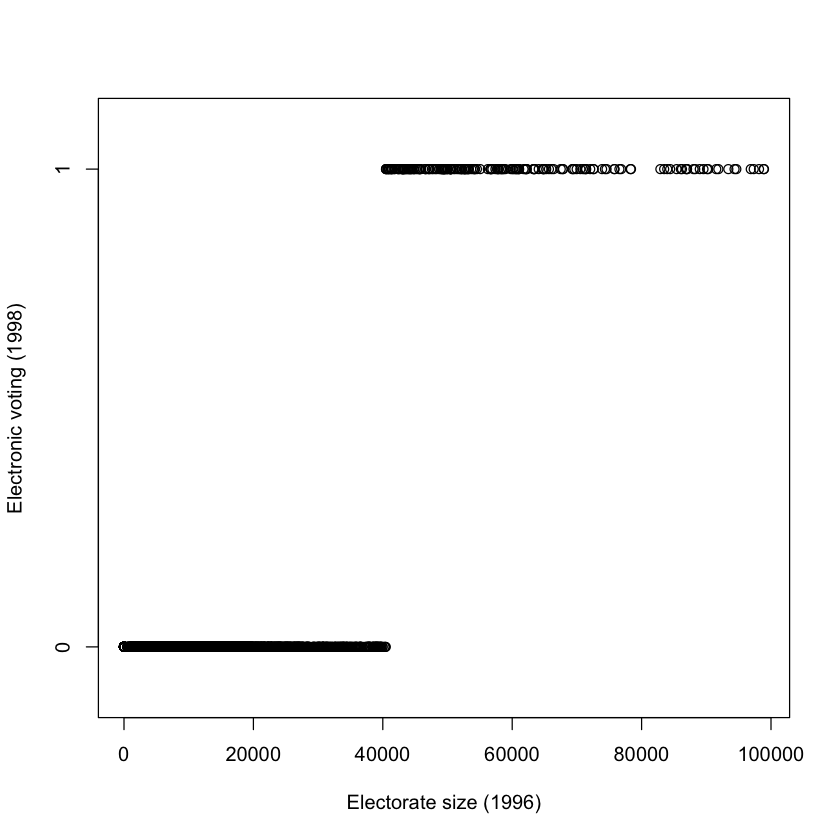

In [6]:
# subset to only municipalities with between 0 and 100,000 voters
full_brazil_data <- subset(brazil.data, electorate.96>=0 & electorate.96 <= 100000) 

options(scipen = 999) # use the raw numbers, not scientific notation 

# Create the plot (don't worry about the options used to format the x- and y-axes now)
# Note that the x variable is electorate.96 and the y
plot(full_brazil_data$electorate.96,full_brazil_data$comp.voting.98, xlab="Electorate size (1996)",ylab="Electronic voting (1998)", ylim = c(-0.1, 1.1), yaxt = "n")
axis(side = 2, at = c(0, 1), labels = c("0", "1"))

This looks good!  All of the municipalities with fewer than 40,500 voters used the status-quo paper-based system, so there was no electronic voting (so `comp.voting.98=0`).  Those municipalities with 40,500 voters or more, by contrast, did use electronic voting (so `comp.voting.98=1`).

## What is the effect of electronic voting?

Having verified that the rule assigning electronic voting to was in fact implemented, let's now consider how to use the data to estimate the effect of electronic voting.

One of the best things to do first in any study is to look at the data visually, with graphs and plots.  In addition to getting a sense of the likely scale of any treatment effects---that is, any differences in the average values of the outcome variable on either side of the discontinuity--plots can help you spot any issues with data processing or other problems that need to be addressed.

We are going to use a special plot created by a package called `rdrobust` package in R.  (We loaded this package at the top of this Notebook.  If you really want, you can read more details about the package <a href="https://cran.r-project.org/web/packages/rdrobust/rdrobust.pdf">here</a>). 

The function from `rdrobust` we will use is called `rdplot`.  To create the plot, we need to specify at a minimum the outcome variable (for the vertical axis), the forcing/assignment/running variable (for the horizontal axis), and the cutoff value that determines treatment assignment.

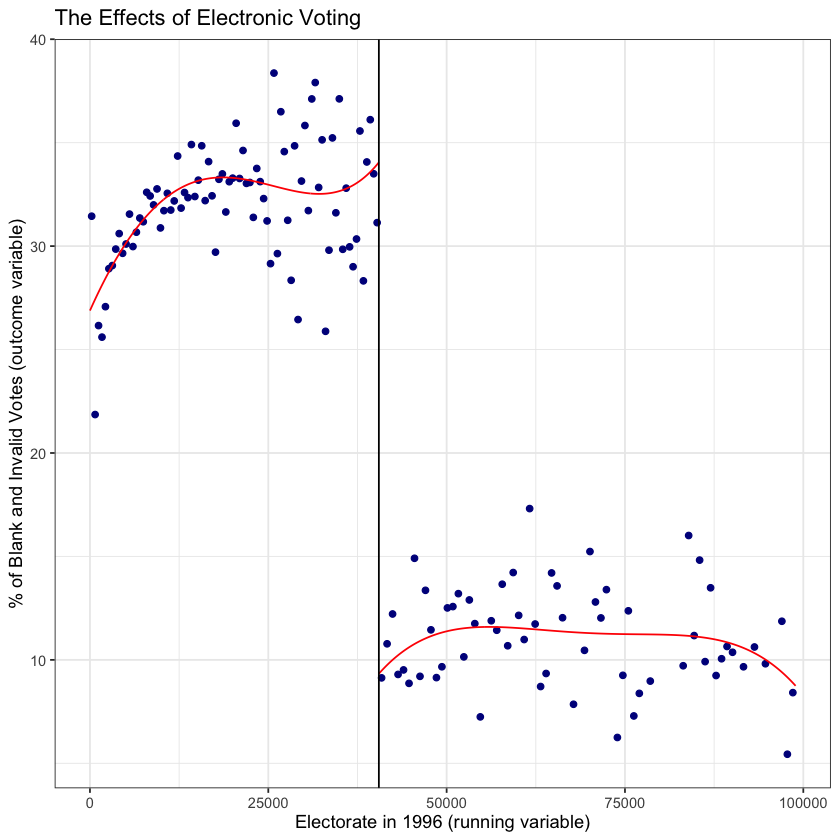

In [15]:
# Run this cell
rdplot(full_brazil_data$depfedbranconulo98.pct, full_brazil_data$electorate.96, c=40500, x.label="Electorate in 1996 (running variable)", y.label="% of Blank and Invalid Votes (outcome variable)", title="The Effects of Electronic Voting")



A few notes about what we are seeing here:
- The vertical line is placed at the cutoff value for treatment assignment, i.e., 40,500 voters in this study. The `c=40,500` argument in our call of rdplot makes this magic happen.
- The points in this plot are binned averages.  This means that for a narrow bin (say, between 40,500 and 41,000 voters), the function calculates the average of the outcome variable and creates a point for the average.  (Note that this makes the plot look a little different from Hidalgo's plot we saw in lecture -- there, we saw all the raw outcome data, not just the average value for municipalities within each bin).
- The red lines approximate the shape of the binned averages above and below the threshold of 40,500. But don't worry much about this yet!  (We'll return to this idea in two weeks, when we study regression).

It certainly looks like there is a big difference in the percentage of spoiled ballots above and below the threshold!  This strongly suggests that electronic voting machines reduce the rate of blank and invalid votes.  But we will return shortly to formal analysis of the treatment effect.

### The syntax for rdplot

The general syntax for `rdplot()` is

`rdplot(y, x, c=...)`

where y is the outcome variable, x is the running variable, and you put the cutoff value in place of `...` (If you don't specify `c=...`, the cutoff is 0 by default).  You can add some other options (like the axis labels and the title in the plot we drew), but we won't worry about that now.  

Note that y comes first, then x!  This is different from the `plot()` function we learned before, where x came first, then y.  There are some other options you can add to `rdplot()` but don't worry about that for now.  

This is on the R Cheat Sheet!

# Estimating the effects of electronic voting: two techniques

The plot above strongly suggests that the introduction of electronic voting in Brazil reduced the rate of null and invalid votes. But how should we formally analyze and estimate the treatment effect in a discontinuity design?  

Let's discuss the advantages and disadvantages of two possible techniques: 
(1) the difference of means in a narrow bandwidth; and 
(2) the difference of interepts.

## The difference of means

In some discontinuity designs, it may make sense simply to look at the average of the outcome variable above and below the threshold, in a narrow bandwidth around the cutoff.  Let's take that approach first with the Hidalgo data.

First, we need to decide what constitutes a narrow bandwidth around the cutoff -- i.e., how close is "close enough" to the threshold that the assignment to the treatment (electronic voting) should be considered essentially random?

We'll talk more about selecting a bandwidth in a minute, but for now, let's just use the definition that the author uses in this paper: 
- "I use a bandwidth of 5,000 voters, leaving municipalities with a 1996 electorate greater than 35,500 and lower than 45,500, for a total of 114 municipalities" (see p. 17 of the Hidalgo paper, which is the optional reading for this week posted on bCourses). 

So, analyzing the data involves two steps:
- Creating the subset of data for this bandwidth; and
- Using the `difference_in_means()` function (that you already know how to use) to estimate the average treatment effect, given this bandwidth.

(Note that Hidalgo also uses a difference-of-intercepts approach, which we will discuss next) to estimate effects).

Let's implement this first approach using the `difference_in_means()` function:


In [20]:
# First, we subset to the bandwidth used by Hidalgo: municipalities with a 1996 electorate greater than 35,500 and lower than 45,500
close_brazil_data <- subset(brazil.data, electorate.96>=35500 & electorate.96 <= 45500)

# We can verify this leaves 114 observations by using the function nrow(), which tells us the number of rows in close_brazil_data
nrow(close_brazil_data)


[1] 114

In [21]:
# Now use the treatment variable, i.e., comp.voting.98
# Note that comp.voting.98=1 for municipalities with electorates above the threshold of 40,500 and otherwise comp.voting.98=0
difference_in_means(depfedbranconulo98.pct ~ comp.voting.98, close_brazil_data)

Design:  Standard 
                Estimate Std. Error   t value
comp.voting.98 -23.06958   1.082136 -21.31855
                                                        Pr(>|t|)  CI Lower
comp.voting.98 0.00000000000000000000000000000000000000009038604 -25.21423
                CI Upper       DF
comp.voting.98 -20.92493 109.4851

The estimate of a reduction of 23 percentage points in the rate of blank and null votes is about what we might guess just from inspecting the plot we made above.  This is a very big apparent treatment effect. (Also, look at that huge *t*-statistic and vanishingly small *p*-value!).

#### Advantages and disadvantages of using difference_in_means()
This approach using `difference_in_means()` has some key advantages: 

- It is simple to calculate and transparent.
- It relies on a core feature of the discontinuity design---i.e. the idea that near the threshold, it is almost as if there is a "local" randomized experiment. (So, just like in a real experiment, we can use `difference_in_means()` to estimate treatment effects).
- Finally, finding evidence of an effect using `difference_in_means()` might operate as a "sine qua non" (that is, a "without which not") for evidence of a treatment effect. After all, if you don't find a discernible difference in the average values of the outcome variable just above and just below the threshold, it seems unlikely that the treatment in fact had an effect.
    
The approach also has **two key problems**, however:
1. How should we choose the bandwidth -- i.e., what is a "narrow bandwidth around the cutoff"?
2. The approach may work less well when the outcome variable is strongly related to the running variable. 

The **first problem** is a common challenge in discontinuity designs, no matter what technique we use to estimate the treatment effects. 

Some methodological research in political science and economics seeks to use algorithms to find an "optimal" bandwidth--optimal because it is big enough to include enough data to reduce standard errors but not being so big as to risk substantial bias that is due to points far from the threshold being included.  

Other researchers proceed more substantively, by thinking about what bandwidths it would require in a given context for local randomization to be plausible and then using balance tests and other techniques to test the assumption of as-if random. (We will discuss balance tests below). 

Finally, many researchers estimate treatment effects with a range of bandwidths, to see whether or not findings are stable across different bandwidths in a given context. We will do this in the in-class assignment this week, using Hidalgo's Brazil data.

The **second problem** is specific to use of `difference_in_means()` to estimate the effect. 

To understand this problem, suppose the outcome variable is higher at bigger values of the running variable. (That is, there is a positive relationship: if you plotted a line relating the outcome variable on the vertical axis to the running variable on the horizontal axis, the slope of hte line would be positive). 

In that case, even in fairly narrow bandwidths around the cutoff, differences in the average outcome above and below the cuttoff could simply reflect the upward-sloping relationship between the outcome and the running variable---rather than any effect of the treatment.

This second problem leads to another way in which researchers try to estimate effects in discontinuity designs---as the difference in intercepts.  

## The difference of intercepts

Let's discuss that idea briefly here.  We won't delve that much into the details, partly because we will discuss regression more extensively in 2-3 weeks.  

But the key idea is to fit functions like the red curves in the RD plot, above and below the threshold.  These could be lines rather than curves (we'll discuss that when we get to linear regression), or they could be more flexible functions like those shown in the plot.

However we fit the functions, the key idea is that the difference of the intercepts---exactly at the point of discontinuity, i.e., the key threshold value of the assignment variable---estimates the treatment effect.  In Hidalgo's study of voting machines in Brazil, we take the difference between the intercepts at the threshold of 40,500 voters.

There is a function, called `rdrobust()` that is also part of the `rdrobust` package (the function and the package have the same name), that makes this easy to do. 

The full `rdrobust()` prints out a lot of details that we won't get into now -- and **that you do not need to understand now**.  Here, we have just the syntax for running the function and then printing out the estimate, that is, the difference of the intercepts.

In [37]:
# Run the rdrobust function with depfedbranconulo98.pct as the outcome, 
# electorate.96 as the running variable, and 
# c=40500 for the cutoff
diff_of_intercepts <- rdrobust(full_brazil_data$depfedbranconulo98.pct, full_brazil_data$electorate.96, c=40500)

# Print out the estimate of the difference of intercepts
diff_of_intercepts$coef[1]

[1] -23.56197

So the estimate---the difference of intercepts---is -23.56.  That's almost exactly what we found with the `difference_in_means()` function above, where the estimate as -23.06958.

This won't always be the case: in some discontinuity designs, the difference of intercepts might be quite different from the simple difference of means. But it is reassuring when they coincide, like they do here.

#### Advantages and disadvantages of the difference of intercepts

The main advantage of this difference-in-intercepts approach is that it does not suffer from the main problem with the difference in means. 

That is, it does not have the problem that when the outcome variable is related to the running variable, differences in average values on either side of the threshold might simply reflect this association---rather than true treatment effects.  

Note that the outcome variable is not always related to the running variable---it depends on the particular RD design.  In Hidalgo's study, the size of the municipal electorate does not appear to be very related to the rate of null and invalid votes (consider for example the effect plot we looked at in the in-class lecture, and also our rdplot() above). In other RD designs, the outcome and running variables might be more strongly related, and this would be a reason to rely on the difference of intercepts.

However, the main disadvantage of the difference of intercepts is that it also involves modeling the functional relationship between the outcome and the running variable (like in rdplot() above) and therefore may not be as simple and transparent as the difference of means.  

We'll talk more about this modeling issue in our weeks on regression.


# Balance tests in discontinuity designs

Let's consider a final issue: how do we test an assumption such as (local) as-if random assignment to the treatment in a discontinuity design?

One technique is to check for balance on covariates, comparing the treatment and control groups near the threshold.  

We discussed this approach in the in-class lecture and described the potential value of using the lagged value of the outcome -- which may be highly prognostic, that is, predictive of post-treatment outcomes. 

Let's do that analysis here.  We simply replicate our earlier analysis using `difference_in_means()` -- but instead of using the outcome variable `depfedbranconulo98.pct` as the dependent variable, we use the pre-treatment covariate `blank.inv.96`.

As before, we want to use the subset of the data in the small (5,000 voter) bandwidth:

In [29]:
difference_in_means(blank.inv.96 ~ comp.voting.98, close_brazil_data)

Design:  Standard 
                Estimate Std. Error    t value  Pr(>|t|)  CI Lower CI Upper
comp.voting.98 -0.405507   0.892368 -0.4544168 0.6511212 -2.189447 1.378433
                     DF
comp.voting.98 61.78832

The estimate is small (-0.406) and statistically insignificant (*p*-value is 0.65).  Compare this to the extremely significant difference of about 23 percentage points when using `depfedbranconulo98.pct` to estimate the treatment effect!

So far, we just assumed that the pre-treatment (or "lagged") outcome variable is correlated with its post-treatment value---i.e., the true outcome.  But we can also check this empirically as follows:

In [32]:
# Subset to the control group in the full data set
# That way, we can assess the correlation of the pre-treatment covariate with the potential outcomes under control---which is what
# we observe in the control group
full_brazil_data_control <- subset(full_brazil_data, comp.voting.98==0)

# Now, assess the correlation:
cor(full_brazil_data_control$blank.inv.96,full_brazil_data_control$depfedbranconulo98.pct)

[1] 0.4923812

The correlation is indeed very strong: the lagged "outcome" is prognostic of the true outcome.

### What we have learned

We've learned some key aspects of the analysis of discontinuity designs---which are now very widely used in the political science as well as economics.  You will certainly encounter these kinds of designs in your other classes!

- We learned how to check whether the threshold in a discontinuity design in fact leads to a difference in treatment status.
- We learned how to use `rdplot` in the `rdrobust` package to create the typical graph used in discontinuity designs to inspect the data visually for any evidence of a treatment effect.
- We learned how to subset the data to a narrower bandwidth around the threshold and estimate a treatment effect using `difference_in_means()`.
- We also discussed (in less detail) how to estimate an effect using the difference in intercepts of functions on either side of the threshold (using the `rdrobust()` function in the package with the same name).
- Finally, we learned how to test key assumptions of these designs using pre-treatment covariates.  The more predictive these pre-treatment covariates are of the outcome, the better.

### The in-class activity on Tuesday, March 31

In Tuesday's in-class activity, you will practice what you have learned here and in the in-class lecture to do the following:
- Answer a few multiple-choice conceptual questions about discontinuity designs;
- Estimate treatment effects using the `difference_of_means()` function, like we did above, but for bigger and smaller bandwidths (i.e., using bigger and smaller subsets of data around the cutoff), and also do balance tests on pre-treatment covariates.
- Use `rdplot()` to graph the relationship between one pre-treatment covariate and the running variable.

Between the in-class lecture, this recorded lecture, and sections, you will have all the material you need!